# MFE Model Evaluation � notebooks_8/04

Evaluates `models_9/mfe_q50` and `models_9/3_quants` (Q25/Q50/Q75) on out-of-sample data (post 2024-06-30).

In [5]:
import pandas as pd
import numpy as np
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')
from pathlib import Path

FEATURES_DIR = Path('../backend/data/features_9')
PRICE_DIR    = Path('../backend/data/processed')
MODELS_DIR   = Path('../backend/models_9')

MAJORS    = ['EURUSD', 'GBPUSD', 'USDJPY', 'USDCHF', 'USDCAD', 'AUDUSD', 'NZDUSD']
TRAIN_END = '2024-06-30'
HORIZON   = 72  # MFE horizon in bars (1H bars = 72H)

SPREADS = {
    'EURUSD': 0.2 * 0.0001,
    'GBPUSD': 0.4 * 0.0001,
    'USDJPY': 0.3 * 0.01 / 150,
    'USDCHF': 0.4 * 0.0001,
    'USDCAD': 0.4 * 0.0001,
    'AUDUSD': 0.3 * 0.0001,
    'NZDUSD': 0.5 * 0.0001,
}

print('Ready.')


Ready.


## 1. Load Models

In [6]:
bundle_q50 = joblib.load(MODELS_DIR / 'mfe_q50' / 'model_1H_Q50.joblib')
bundle_q25 = joblib.load(MODELS_DIR / '3_quants' / 'model_1H_Q25.joblib')
bundle_q75 = joblib.load(MODELS_DIR / '3_quants' / 'model_1H_Q75.joblib')

feature_cols = bundle_q50['feature_cols']
print(f'Features: {len(feature_cols)}')
print(f'Q50 model � iters: {bundle_q50["n_iters"]}  cv_pinball: {bundle_q50["cv_pinball"]:.4f}')
print(f'Q25 model � iters: {bundle_q25["n_iters"]}')
print(f'Q75 model � iters: {bundle_q75["n_iters"]}')


Features: 320
Q50 model � iters: 423  cv_pinball: 8.1501
Q25 model � iters: 799
Q75 model � iters: 841


## 2. Load Test Data & Compute True MFE

In [7]:
all_feature_cols = list(set(
    bundle_q50['feature_cols'] + bundle_q25['feature_cols'] + bundle_q75['feature_cols']
))

dfs = []
for pair in MAJORS:
    print(f'  {pair}...', flush=True)

    feat = pd.read_parquet(FEATURES_DIR / f'{pair}_features.parquet')
    present = [c for c in all_feature_cols if c in feat.columns]
    feat = feat[present].ffill().fillna(0).astype(np.float32)

    price = pd.read_parquet(PRICE_DIR / f'{pair}_1H.parquet')
    high  = price['high'].reindex(feat.index)
    low   = price['low'].reindex(feat.index)
    close = price['close'].reindex(feat.index)

    pip = 0.01 if 'JPY' in pair else 0.0001
    n = len(feat)
    mfe_true = np.full(n, np.nan)
    for i in range(n - HORIZON):
        mfe_true[i] = (high.iloc[i+1:i+HORIZON+1].max() - close.iloc[i]) / pip

    feat['mfe_true'] = mfe_true
    feat['pair']     = pair
    dfs.append(feat[feat.index > TRAIN_END])
    del feat; gc.collect()

df_test = pd.concat(dfs).sort_index(); del dfs; gc.collect()
print(f'Test rows: {len(df_test):,}  ({df_test.index.min().date()} -> {df_test.index.max().date()})')


  EURUSD...
  GBPUSD...
  USDJPY...
  USDCHF...
  USDCAD...
  AUDUSD...
  NZDUSD...
Test rows: 64,951  (2024-06-30 -> 2025-12-31)


## 3. Predict

In [8]:
valid     = df_test['mfe_true'].notna()
df_valid  = df_test[valid]
mfe_true  = df_valid['mfe_true'].values
pair_test = df_valid['pair']
idx_test  = df_valid.index

def make_X(df, feature_cols):
    n = len(df)
    X = np.zeros((n, len(feature_cols)), dtype=np.float32)
    for i, c in enumerate(feature_cols):
        if c in df.columns:
            X[:, i] = df[c].values
    return X

X_q50 = make_X(df_valid, bundle_q50['feature_cols'])
X_q25 = make_X(df_valid, bundle_q25['feature_cols'])
X_q75 = make_X(df_valid, bundle_q75['feature_cols'])

pred_q50 = bundle_q50['model'].predict(X_q50)
pred_q25 = bundle_q25['model'].predict(X_q25)
pred_q75 = bundle_q75['model'].predict(X_q75)
del X_q50, X_q25, X_q75; gc.collect()

results = pd.DataFrame({
    'mfe_true': mfe_true,
    'pred_q25': pred_q25,
    'pred_q50': pred_q50,
    'pred_q75': pred_q75,
    'pair':     pair_test.values,
}, index=idx_test)

print(f'Predictions: {len(results):,} rows')
print(f'True MFE — mean: {mfe_true.mean():.1f} pips  median: {np.median(mfe_true):.1f}  p75: {np.percentile(mfe_true,75):.1f}  p90: {np.percentile(mfe_true,90):.1f}')
print(f'Pred Q50 — mean: {pred_q50.mean():.1f} pips  median: {np.median(pred_q50):.1f}  p75: {np.percentile(pred_q50,75):.1f}  p90: {np.percentile(pred_q50,90):.1f}')


Predictions: 63,146 rows
True MFE — mean: 70.2 pips  median: 51.7  p75: 93.6  p90: 148.7
Pred Q50 — mean: 32.9 pips  median: 27.9  p75: 36.3  p90: 50.7


## 4. Pinball Loss & Calibration

In [9]:
def pinball(y, q_pred, q):
    e = y - q_pred
    return np.where(e >= 0, q * e, (q - 1) * e).mean()

pb25 = pinball(mfe_true, pred_q25, 0.25)
pb50 = pinball(mfe_true, pred_q50, 0.50)
pb75 = pinball(mfe_true, pred_q75, 0.75)
print(f'Pinball loss � Q25: {pb25:.4f}  Q50: {pb50:.4f}  Q75: {pb75:.4f}')
print(f'(CV pinball was {bundle_q50["cv_pinball"]:.4f} � lower is better)')

# Coverage: % of true MFE above predicted quantile (should match quantile level)
cov25 = (mfe_true > pred_q25).mean()
cov50 = (mfe_true > pred_q50).mean()
cov75 = (mfe_true > pred_q75).mean()
print(f'\nCoverage (should be ~75%, ~50%, ~25%):')
print(f'  Q25: {cov25:.1%}  Q50: {cov50:.1%}  Q75: {cov75:.1%}')

# Calibration by decile of pred_q50
print(f'\nCalibration by pred_q50 decile:')
print(f'  {"Decile":<10} {"N":>6} {"Pred Q50":>10} {"True MFE":>10} {"Coverage50":>12}')
print('  ' + '-'*52)
deciles = pd.qcut(results['pred_q50'], 10, labels=False)
for d in range(10):
    mask = deciles == d
    p    = results.loc[mask, 'pred_q50'].mean()
    t    = results.loc[mask, 'mfe_true'].mean()
    cov  = (results.loc[mask, 'mfe_true'] > results.loc[mask, 'pred_q50']).mean()
    print(f'  D{d+1:<9} {mask.sum():>6,} {p:>10.1f} {t:>10.1f} {cov:>12.1%}')


Pinball loss � Q25: 17.5600  Q50: 24.2983  Q75: 52.6707
(CV pinball was 8.1501 � lower is better)

Coverage (should be ~75%, ~50%, ~25%):
  Q25: 99.9%  Q50: 69.7%  Q75: 99.8%

Calibration by pred_q50 decile:
  Decile          N   Pred Q50   True MFE   Coverage50
  ----------------------------------------------------
  D1          6,315       18.1       43.0        72.5%
  D2          6,315       21.0       45.4        69.2%
  D3          6,314       22.9       49.4        69.8%
  D4          6,315       24.7       53.4        69.7%
  D5          6,314       26.7       60.0        70.2%
  D6          6,315       29.2       65.7        71.0%
  D7          6,314       32.2       71.3        70.4%
  D8          6,315       36.4       89.5        71.8%
  D9          6,314       44.4      104.2        72.6%
  D10         6,315       72.9      120.3        59.8%


## 5. Signal Quality � Does High Prediction Mean Big True Move?

In [10]:
# Key question: when model predicts high MFE, does a big move actually happen?
thresholds = [10, 15, 20, 25, 30, 40]
print(f'{"Pred Q50 >":<12} {"N":>6} {"N/mo":>6} {"TrueMFE mean":>14} {"True>thresh%":>14} {"True>2x pred%":>14}')
print('=' * 75)
nm = (results.index.max() - results.index.min()).days / 30
for t in thresholds:
    mask = results['pred_q50'] > t
    if mask.sum() < 50: continue
    sub      = results[mask]
    true_mean = sub['mfe_true'].mean()
    true_above = (sub['mfe_true'] > t).mean()
    above_2x   = (sub['mfe_true'] > 2 * sub['pred_q50']).mean()
    npm = mask.sum() / nm
    print(f'{t:<12} {mask.sum():>6,} {npm:>6.0f} {true_mean:>14.1f} {true_above:>14.1%} {above_2x:>14.1%}')


Pred Q50 >        N   N/mo   TrueMFE mean   True>thresh%  True>2x pred%
10           63,146   3489           70.2          89.0%          44.8%
15           63,007   3481           70.3          83.7%          44.7%
20           56,358   3114           73.5          79.6%          44.2%
25           40,176   2220           83.4          78.3%          44.1%
30           26,419   1460           95.1          77.9%          43.8%
40           12,097    668          113.0          76.1%          40.9%


## 6. Per-Pair Breakdown

In [11]:
print(f'Per-pair � Q50 prediction quality:')
print(f'  {"Pair":<10} {"N":>6} {"PredMean":>10} {"TrueMean":>10} {"Pinball":>10} {"Cov50":>8}')
print('  ' + '-'*55)
for pair in sorted(results['pair'].unique()):
    p   = results[results['pair'] == pair]
    pb  = pinball(p['mfe_true'].values, p['pred_q50'].values, 0.50)
    cov = (p['mfe_true'] > p['pred_q50']).mean()
    print(f'  {pair:<10} {len(p):>6,} {p["pred_q50"].mean():>10.1f} {p["mfe_true"].mean():>10.1f} {pb:>10.4f} {cov:>8.1%}')


Per-pair � Q50 prediction quality:
  Pair            N   PredMean   TrueMean    Pinball    Cov50
  -------------------------------------------------------
  AUDUSD      8,931       26.6       47.9    15.5489    67.6%
  EURUSD      9,019       28.8       72.2    25.5436    73.3%
  GBPUSD      9,030       33.6       83.7    29.5877    73.8%
  NZDUSD      9,040       29.4       45.8    15.2949    61.3%
  USDCAD      9,044       33.6       65.6    22.6654    70.4%
  USDCHF      9,041       27.3       52.3    17.1619    68.2%
  USDJPY      9,041       50.5      123.8    44.1884    73.2%


## 7. Distribution of Predictions vs True MFE

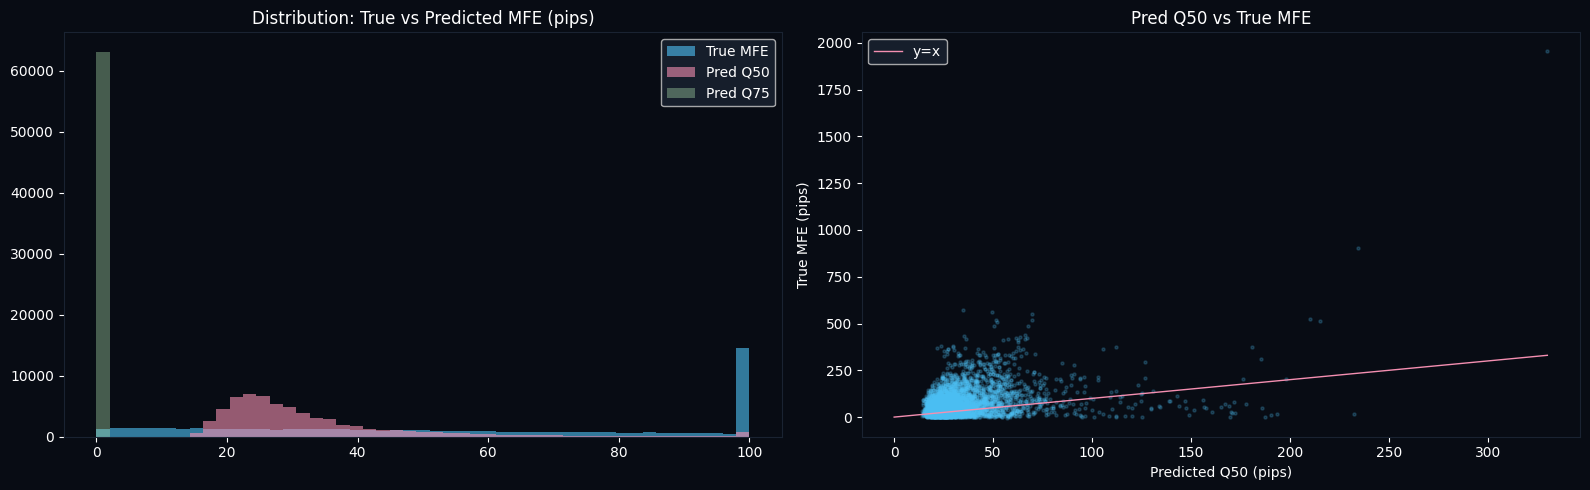

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#080c14')

# Left: histogram of pred vs true
ax = axes[0]
ax.set_facecolor('#080c14')
bins = np.linspace(0, 100, 50)
ax.hist(np.clip(mfe_true, 0, 100),  bins=bins, alpha=0.6, color='#4fc3f7', label='True MFE')
ax.hist(np.clip(pred_q50, 0, 100),  bins=bins, alpha=0.6, color='#f48fb1', label='Pred Q50')
ax.hist(np.clip(pred_q75, 0, 100),  bins=bins, alpha=0.4, color='#a5d6a7', label='Pred Q75')
ax.set_title('Distribution: True vs Predicted MFE (pips)', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2332', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Right: scatter pred_q50 vs true (sampled)
ax = axes[1]
ax.set_facecolor('#080c14')
sample = results.sample(min(5000, len(results)), random_state=42)
ax.scatter(sample['pred_q50'], sample['mfe_true'], alpha=0.2, s=5, color='#4fc3f7')
lim = max(sample['pred_q50'].max(), sample['mfe_true'].quantile(0.95))
ax.plot([0, lim], [0, lim], color='#f48fb1', linewidth=1, label='y=x')
ax.set_xlabel('Predicted Q50 (pips)', color='white')
ax.set_ylabel('True MFE (pips)', color='white')
ax.set_title('Pred Q50 vs True MFE', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2332', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.tight_layout()
plt.show()
